In [ ]:
import requests
import pandas as pd
import numpy as np

In [ ]:
url = "https://api.github.com/search/repositories"

params = {
    "q": "stars:>1000",
    "sort": "stars",
    "order": "desc",
    "per_page": 100
}

response = requests.get(url, params=params)

print(response.status_code)

200


In [ ]:
data = response.json()

df = pd.DataFrame(data["items"])

df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,132750724,MDEwOlJlcG9zaXRvcnkxMzI3NTA3MjQ=,build-your-own-x,codecrafters-io/build-your-own-x,False,"{'login': 'codecrafters-io', 'id': 58904235, '...",https://github.com/codecrafters-io/build-your-...,Master programming by recreating your favorite...,False,https://api.github.com/repos/codecrafters-io/b...,...,False,True,all,"[awesome-list, free, programming, tutorial-cod...",public,51036,633,540752,master,1.0
1,21737465,MDEwOlJlcG9zaXRvcnkyMTczNzQ2NQ==,awesome,sindresorhus/awesome,False,"{'login': 'sindresorhus', 'id': 170270, 'node_...",https://github.com/sindresorhus/awesome,😎 Awesome lists about all kinds of interesting...,False,https://api.github.com/repos/sindresorhus/awesome,...,False,True,all,"[awesome, awesome-list, lists, resources, unic...",public,36465,102,497265,main,1.0
2,54346799,MDEwOlJlcG9zaXRvcnk1NDM0Njc5OQ==,public-apis,public-apis/public-apis,False,"{'login': 'public-apis', 'id': 51121562, 'node...",https://github.com/public-apis/public-apis,A collective list of free APIs,False,https://api.github.com/repos/public-apis/publi...,...,False,True,all,"[api, apis, dataset, development, free, list, ...",public,51270,1688,463961,master,1.0
3,28457823,MDEwOlJlcG9zaXRvcnkyODQ1NzgyMw==,freeCodeCamp,freeCodeCamp/freeCodeCamp,False,"{'login': 'freeCodeCamp', 'id': 9892522, 'node...",https://github.com/freeCodeCamp/freeCodeCamp,freeCodeCamp.org's open-source codebase and cu...,False,https://api.github.com/repos/freeCodeCamp/free...,...,True,True,all,"[careers, certification, community, curriculum...",public,46005,275,454251,main,1.0
4,13491895,MDEwOlJlcG9zaXRvcnkxMzQ5MTg5NQ==,free-programming-books,EbookFoundation/free-programming-books,False,"{'login': 'EbookFoundation', 'id': 14127308, '...",https://github.com/EbookFoundation/free-progra...,:books: Freely available programming books,False,https://api.github.com/repos/EbookFoundation/f...,...,False,True,all,"[books, education, hacktoberfest, list, resource]",public,66671,81,394671,main,1.0


In [ ]:
print(df.shape)

(100, 82)


In [ ]:
print(df.columns)

Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [ ]:
df["owner_name"] = df["owner"].apply(
    lambda x: x["login"] if isinstance(x, dict) else np.nan
)

In [ ]:
df["license_name"] = df["license"].apply(
    lambda x: x["spdx_id"] if isinstance(x, dict) else np.nan
)

In [ ]:
df = df[
    [
        "name",
        "owner_name",
        "description",
        "language",
        "stargazers_count",
        "forks_count",
        "open_issues_count",
        "watchers_count",
        "license_name",
        "created_at",
        "updated_at"
    ]
]

In [ ]:
df.isnull().sum()

,0
name,0
owner_name,0
description,0
language,13
stargazers_count,0
forks_count,0
open_issues_count,0
watchers_count,0
license_name,10
created_at,0


In [ ]:
df["description"] = df["description"].fillna("Unknown")
df["language"] = df["language"].fillna("Unknown")
df["license_name"] = df["license_name"].fillna("Unknown")

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

In [ ]:
df = df.rename(columns={
    "name": "repository_name",
    "stargazers_count": "stars",
    "forks_count": "forks",
    "open_issues_count": "open_issues",
    "watchers_count": "watchers"
})

In [ ]:
df.to_csv("github_projects.csv", index=False)

In [ ]:
df_check = pd.read_csv("github_projects.csv")

print(df_check.shape)
df_check.head()

(100, 11)


,repository_name,owner_name,description,language,stars,forks,open_issues,watchers,license_name,created_at,updated_at
0,build-your-own-x,codecrafters-io,Master programming by recreating your favorite...,Markdown,540752,51036,633,540752,Unknown,2018-05-09 12:03:18+00:00,2026-08-18 15:01:35+00:00
1,awesome,sindresorhus,😎 Awesome lists about all kinds of interesting...,Unknown,497265,36465,102,497265,CC0-1.0,2014-07-11 13:42:37+00:00,2026-08-18 15:02:28+00:00
2,public-apis,public-apis,A collective list of free APIs,Python,463961,51270,1688,463961,MIT,2016-03-20 23:49:42+00:00,2026-08-18 15:01:34+00:00
3,freeCodeCamp,freeCodeCamp,freeCodeCamp.org's open-source codebase and cu...,TypeScript,454251,46005,275,454251,BSD-3-Clause,2014-12-24 17:49:19+00:00,2026-08-18 14:54:39+00:00
4,free-programming-books,EbookFoundation,:books: Freely available programming books,Python,394671,66671,81,394671,CC-BY-4.0,2013-10-11 06:50:37+00:00,2026-08-18 15:01:26+00:00


In [ ]:
import sqlite3

conn = sqlite3.connect("github_projects.db")

In [ ]:
df.to_sql(
    "Repositories",
    conn,
    if_exists="replace",
    index=False
)

100

In [ ]:
pd.read_sql_query(
    "SELECT * FROM Repositories LIMIT 5",
    conn
)

,repository_name,owner_name,description,language,stars,forks,open_issues,watchers,license_name,created_at,updated_at
0,build-your-own-x,codecrafters-io,Master programming by recreating your favorite...,Markdown,540752,51036,633,540752,Unknown,2018-05-09 12:03:18+00:00,2026-08-18 15:01:35+00:00
1,awesome,sindresorhus,😎 Awesome lists about all kinds of interesting...,Unknown,497265,36465,102,497265,CC0-1.0,2014-07-11 13:42:37+00:00,2026-08-18 15:02:28+00:00
2,public-apis,public-apis,A collective list of free APIs,Python,463961,51270,1688,463961,MIT,2016-03-20 23:49:42+00:00,2026-08-18 15:01:34+00:00
3,freeCodeCamp,freeCodeCamp,freeCodeCamp.org's open-source codebase and cu...,TypeScript,454251,46005,275,454251,BSD-3-Clause,2014-12-24 17:49:19+00:00,2026-08-18 14:54:39+00:00
4,free-programming-books,EbookFoundation,:books: Freely available programming books,Python,394671,66671,81,394671,CC-BY-4.0,2013-10-11 06:50:37+00:00,2026-08-18 15:01:26+00:00


In [ ]:
query = """
SELECT repository_name, stars, language
FROM Repositories
WHERE stars > 10000
"""

pd.read_sql_query(query, conn)

,repository_name,stars,language
0,build-your-own-x,540752,Markdown
1,awesome,497265,Unknown
2,public-apis,463961,Python
3,freeCodeCamp,454251,TypeScript
4,free-programming-books,394671,Python
...,...,...,...
95,immich,111508,TypeScript
96,awesome-mac,111357,Swift
97,tauri,110323,Rust
98,TypeScript,110189,TypeScript


In [ ]:
query = """
SELECT repository_name, stars, language
FROM Repositories
WHERE language = 'Python'
AND stars > 5000
"""

pd.read_sql_query(query, conn)

,repository_name,stars,language
0,public-apis,463961,Python
1,free-programming-books,394671,Python
2,system-design-primer,364601,Python
3,awesome-python,314635,Python
4,project-based-learning,279736,Python
5,hermes-agent,232392,Python
6,Python,223832,Python
7,AutoGPT,186664,Python
8,yt-dlp,185298,Python
9,markitdown,174425,Python


In [ ]:
query = """
SELECT repository_name, stars, language
FROM Repositories
WHERE language = 'Python'
OR language = 'JavaScript'
"""

pd.read_sql_query(query, conn)

,repository_name,stars,language
0,public-apis,463961,Python
1,free-programming-books,394671,Python
2,system-design-primer,364601,Python
3,awesome-python,314635,Python
4,project-based-learning,279736,Python
5,react,247406,JavaScript
6,ECC,240855,JavaScript
7,hermes-agent,232392,Python
8,Python,223832,Python
9,javascript-algorithms,196508,JavaScript


In [ ]:
query = """
SELECT repository_name, stars, language
FROM Repositories
WHERE NOT language = 'Python'
"""

pd.read_sql_query(query, conn)

,repository_name,stars,language
0,build-your-own-x,540752,Markdown
1,awesome,497265,Unknown
2,freeCodeCamp,454251,TypeScript
3,openclaw,386637,TypeScript
4,developer-roadmap,364826,TypeScript
...,...,...,...
71,d3,113484,Shell
72,immich,111508,TypeScript
73,awesome-mac,111357,Swift
74,tauri,110323,Rust


In [ ]:
query = """
SELECT repository_name, stars, forks
FROM Repositories
ORDER BY stars DESC
LIMIT 10
"""

top_10 = pd.read_sql_query(query, conn)

top_10

,repository_name,stars,forks
0,build-your-own-x,540752,51036
1,awesome,497265,36465
2,public-apis,463961,51270
3,freeCodeCamp,454251,46005
4,free-programming-books,394671,66671
5,openclaw,386637,81244
6,developer-roadmap,364826,44816
7,system-design-primer,364601,57911
8,coding-interview-university,359124,84653
9,awesome-python,314635,28536


In [ ]:
query = """
SELECT
COUNT(*) AS total_repositories,
AVG(stars) AS average_stars
FROM Repositories
"""

pd.read_sql_query(query, conn)

,total_repositories,average_stars
0,100,188406.37


In [ ]:
query = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
ORDER BY repository_count DESC
"""

language_count = pd.read_sql_query(query, conn)

language_count

,language,repository_count
0,Python,24
1,TypeScript,18
2,Unknown,13
3,JavaScript,9
4,Shell,5
5,Rust,5
6,C++,5
7,Go,4
8,Markdown,3
9,HTML,3


In [ ]:
query = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) >= 3
"""

pd.read_sql_query(query, conn)

,language,repository_count
0,C,3
1,C++,5
2,Go,4
3,HTML,3
4,JavaScript,9
5,Markdown,3
6,Python,24
7,Rust,5
8,Shell,5
9,TypeScript,18


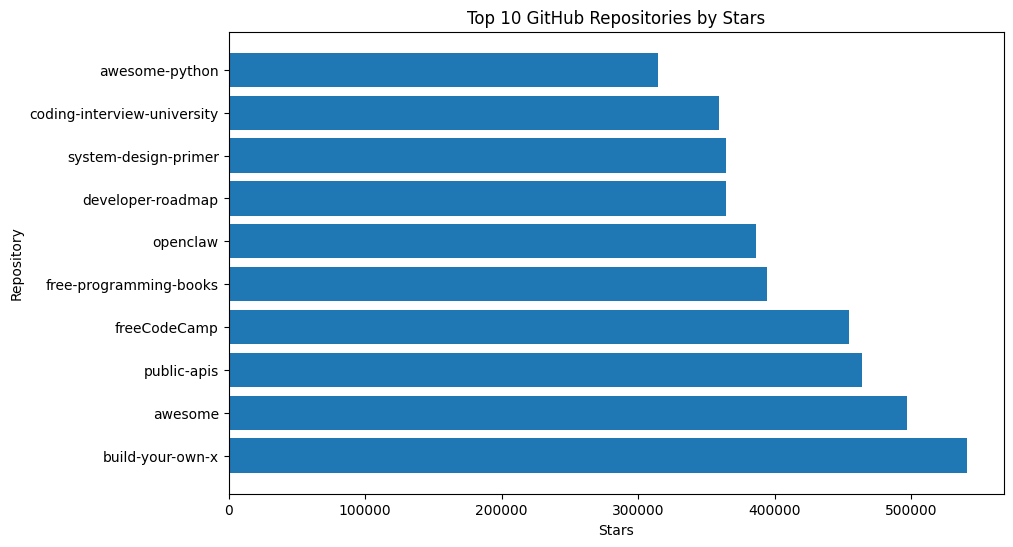

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top_10["repository_name"],
    top_10["stars"]
)

plt.xlabel("Stars")
plt.ylabel("Repository")
plt.title("Top 10 GitHub Repositories by Stars")

plt.show()

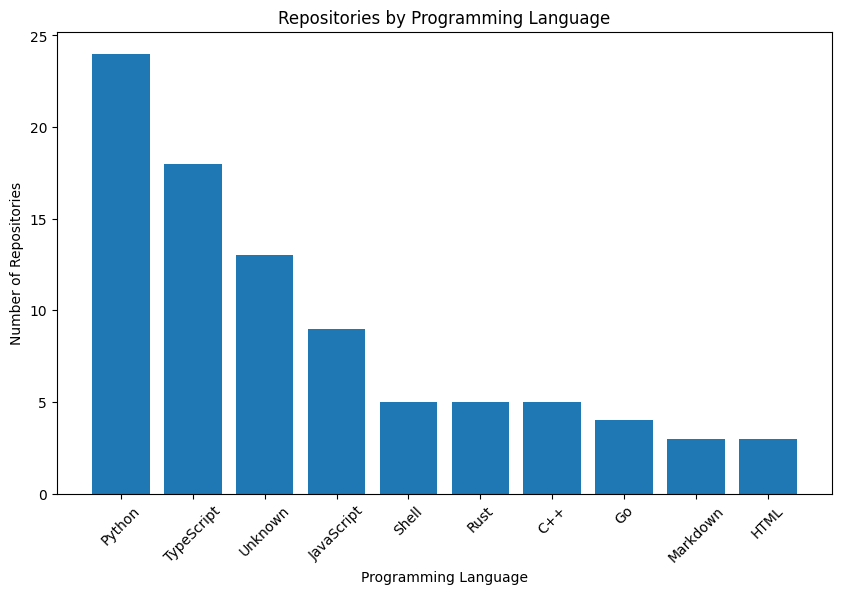

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(
    language_count["language"].head(10),
    language_count["repository_count"].head(10)
)

plt.xlabel("Programming Language")
plt.ylabel("Number of Repositories")
plt.title("Repositories by Programming Language")

plt.xticks(rotation=45)

plt.show()

## Main Findings

- The repository with the highest number of stars is ...
- The most common programming language is ...
- Repositories with more stars tend to have ...